## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 170)

SOURCE = 'csv'          # 'csv' = analytical snapshot | 'sql' = live SQL Server

ROOT = Path.cwd().parent
DATA = ROOT / 'data_clean'
OUT  = ROOT / 'outputs'
OUT.mkdir(exist_ok=True)

DATE_COLS = {'fct_orders': ['order_purchase_timestamp',
                            'order_delivered_customer_date',
                            'order_estimated_delivery_date']}
STR_COLS  = {'dim_customers': {'customer_zip_code_prefix': str},
             'dim_sellers':   {'seller_zip_code_prefix': str}}

def load(table):
    if SOURCE == 'csv':
        return pd.read_csv(DATA / f'{table}.csv',
                           parse_dates=DATE_COLS.get(table, []),
                           dtype=STR_COLS.get(table))
    from sqlalchemy import create_engine
    engine = create_engine('mssql+pyodbc://localhost/olist_ecommerce'
                           '?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes')
    return pd.read_sql(f'SELECT * FROM dbo.{table}', engine,
                       parse_dates=DATE_COLS.get(table, []))

orders         = load('fct_orders')
order_seller   = load('fct_order_seller')
order_category = load('fct_order_category')
customers      = load('dim_customers')
sellers        = load('dim_sellers')
products       = load('dim_products')

tables = {'fct_orders': orders, 'fct_order_seller': order_seller, 'fct_order_category': order_category,
          'dim_customers': customers, 'dim_sellers': sellers, 'dim_products': products}

for name, df in tables.items():
    print(f'{name:20s} {df.shape[0]:>7,d} rows x {df.shape[1]:>2d} cols')

fct_orders            99,421 rows x 22 cols
fct_order_seller      97,819 rows x  8 cols
fct_order_category    97,276 rows x  6 cols
dim_customers         99,441 rows x  5 cols
dim_sellers            3,095 rows x  4 cols
dim_products          32,951 rows x  8 cols


In [2]:
# Visualization settings
INK, MUTED, GRID, BLUE = '#0b0b0b', '#898781', '#e1e0d9', '#2a78d6'

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': GRID, 'axes.labelcolor': MUTED, 'axes.titlecolor': INK,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'xtick.bottom': False, 'ytick.left': False,
    'font.size': 9.5, 'figure.dpi': 110,
})

## 1. Dataset overview

In [3]:
overview = pd.DataFrame([
    ('fct_orders',         'order',            len(orders),         orders.order_id.is_unique),
    ('fct_order_seller',   'order x seller',   len(order_seller),   not order_seller.duplicated(['order_id', 'seller_id']).any()),
    ('fct_order_category', 'order x category', len(order_category), not order_category.duplicated(['order_id', 'product_category']).any()),
    ('dim_customers',      'customer_id',      len(customers),      customers.customer_id.is_unique),
    ('dim_sellers',        'seller_id',        len(sellers),        sellers.seller_id.is_unique),
    ('dim_products',       'product_id',       len(products),       products.product_id.is_unique),
], columns=['table', 'grain', 'rows', 'grain_is_unique'])
overview

,table,grain,rows,grain_is_unique
0,fct_orders,order,99421,True
1,fct_order_seller,order x seller,97819,True
2,fct_order_category,order x category,97276,True
3,dim_customers,customer_id,99441,True
4,dim_sellers,seller_id,3095,True
5,dim_products,product_id,32951,True


In [4]:
print('purchase window   :', orders.order_purchase_timestamp.min().date(), '->', orders.order_purchase_timestamp.max().date())
print(f'orders            : {len(orders):,}   delivered: {orders.is_delivered.sum():,}   reviewed: {orders.has_review.sum():,}')
print('order_status      :', ', '.join(f'{k}={v:,}' for k, v in orders.order_status.value_counts().items()))
print(f'customer_id rows  : {customers.customer_id.nunique():,}   distinct customer_unique_id: {customers.customer_unique_id.nunique():,}')
print(f'avg items / order : {orders.n_items.mean():.2f}   multi-seller orders: {(orders.n_sellers > 1).sum():,}')

purchase window   : 2016-09-04 -> 2018-08-31
orders            : 99,421   delivered: 96,478   reviewed: 98,654
order_status      : delivered=96,478, shipped=1,106, unavailable=609, canceled=606, invoiced=314, processing=301, created=5, approved=2
customer_id rows  : 99,441   distinct customer_unique_id: 96,096
avg items / order : 1.14   multi-seller orders: 1,278


`customer_id` is order-level; `customer_unique_id` identifies the actual customer. Customer-level analysis therefore uses `customer_unique_id`.

## 2. Data quality & validation

### 2.1 Missing values

In [5]:
miss = orders.isna().sum()
miss = miss[miss > 0].to_frame('missing_rows')
miss['pct_of_orders'] = (miss.missing_rows / len(orders) * 100).round(3)
miss

,missing_rows,pct_of_orders
order_delivered_customer_date,2945,2.962
delivery_days,2945,2.962
delay_days,2945,2.962
is_late,2945,2.962
delivery_bucket,2945,2.962
delivery_bucket_order,2945,2.962
review_score,767,0.771
is_negative_review,767,0.771
n_items,756,0.760
n_sellers,756,0.760


In [6]:
no_delivery = orders[orders.order_delivered_customer_date.isna()]
print(f'orders with no delivery date on record : {len(no_delivery):,}')
print(f'  status is not delivered              : {int((no_delivery.is_delivered == 0).sum()):,}')
print(f'  marked delivered but no date (quirk) : {int((no_delivery.is_delivered == 1).sum()):,}')
print(f'orders never reviewed                  : {(orders.has_review == 0).sum():,} ({(orders.has_review == 0).mean()*100:.1f}%)')

orders with no delivery date on record : 2,945
  status is not delivered              : 2,937
  marked delivered but no date (quirk) : 8
orders never reviewed                  : 767 (0.8%)


Reviews are optional, and 8 delivered orders lack a delivery date. So I retained these records and set the affected metrics to NULL rather than excluding them globally.

### 2.2 Grain and business rules

In [7]:
mask = orders.is_late.notna()

assert orders.order_id.is_unique
assert orders.is_delivered.isin([0, 1]).all()
assert (orders.loc[orders.is_delivered == 1, 'order_status'] == 'delivered').all()
assert orders.order_purchase_timestamp.between('2016-09-01', '2018-08-31 23:59:59').all()
assert (orders.review_score.isna() == orders.is_negative_review.isna()).all()
assert (orders.delivery_days.isna() == orders.order_delivered_customer_date.isna()).all()
# 6 cancelled orders were delivered before being cancelled, so a non-delivered
# status can still carry a delivery date
assert orders.loc[orders.is_delivered == 0, 'delivery_days'].notna().sum() == 6
assert (orders.loc[mask, 'is_late'] == (orders.loc[mask, 'delay_days'] > 0).astype('Int64')).all()
assert (orders.delivery_bucket.isna() == orders.order_delivered_customer_date.isna()).all()
assert not order_seller.duplicated(['order_id', 'seller_id']).any()
assert not order_category.duplicated(['order_id', 'product_category']).any()

print("✓ All validation checks passed")

✓ All validation checks passed


### 2.3 Referential integrity

In [8]:
integrity = {
    'fct_orders -> dim_customers':          orders.customer_id.isin(customers.customer_id).mean(),
    'fct_order_seller -> dim_sellers':      order_seller.seller_id.isin(sellers.seller_id).mean(),
    'fct_order_seller -> fct_orders':       order_seller.order_id.isin(orders.order_id).mean(),
    'fct_order_category -> fct_orders':     order_category.order_id.isin(orders.order_id).mean(),
    'every order has >=1 category row':     orders.order_id.isin(order_category.order_id).mean(),
    'every order has >=1 seller row':       orders.order_id.isin(order_seller.order_id).mean(),
}
pd.Series(integrity).mul(100).round(2).to_frame('pct_resolved')

,pct_resolved
fct_orders -> dim_customers,100.00
fct_order_seller -> dim_sellers,100.00
fct_order_seller -> fct_orders,100.00
fct_order_category -> fct_orders,100.00
every order has >=1 category row,97.04
every order has >=1 seller row,97.04


### 2.4 Value ranges

In [9]:
orders[['delivery_days', 'delay_days', 'order_value', 'freight_value', 'n_items', 'review_score']].describe().round(2)

,delivery_days,delay_days,order_value,freight_value,n_items,review_score
count,96476.00,96476.00,98665.00,98665.00,98665.00,98654.00
mean,12.50,-11.88,137.75,22.82,1.14,4.09
std,9.56,10.18,210.65,21.65,0.54,1.35
min,0.00,-147.00,0.85,0.00,1.00,1.00
25%,7.00,-17.00,45.90,13.85,1.00,4.00
50%,10.00,-12.00,86.90,17.17,1.00,5.00
75%,16.00,-7.00,149.90,24.04,1.00,5.00
max,210.00,188.00,13440.00,1794.96,21.00,5.00


In [10]:
print(f'delivery_days > 60 days : {(orders.delivery_days > 60).sum():,}   max: {orders.delivery_days.max()} days')
print(f'order_value  > R$1,000  : {(orders.order_value > 1000).sum():,}   max: R${orders.order_value.max():,.2f}')
print(f'negative order_value    : {(orders.order_value <= 0).sum()}')

delivery_days > 60 days : 298   max: 210.0 days
order_value  > R$1,000  : 943   max: R$13,440.00
negative order_value    : 0


Orders above 60 days are genuine logistics delays rather than data errors, so I retained them for further analysis.

## 3. Analysis base

In [11]:
delivered       = orders[orders.is_delivered == 1].copy()
reviewed        = delivered[delivered.has_review == 1].copy()
reviewed_deliv  = reviewed[reviewed.delivery_days.notna()].copy()
seller_reviewed = order_seller[order_seller.review_score.notna()].copy()
cat_reviewed    = order_category[order_category.review_score.notna()].copy()

# customer grain: one row per real customer
snapshot_date = delivered.order_purchase_timestamp.max() + pd.Timedelta(days=1)
cust = delivered.groupby('customer_unique_id').agg(
    frequency=('order_id', 'nunique'),
    monetary=('order_value', 'sum'),
    last_purchase=('order_purchase_timestamp', 'max'),
)
cust['recency'] = (snapshot_date - cust.last_purchase).dt.days

print(f'orders in scope             : {len(orders):,}')
print(f'  delivered                 : {len(delivered):,}')
print(f'reviewed orders             : {len(reviewed):,}')
print(f'  with a delivery date      : {len(reviewed_deliv):,}')
print(f'order x seller (reviewed)   : {len(seller_reviewed):,}')
print(f'order x category (reviewed) : {len(cat_reviewed):,}')
print(f'customers (unique)          : {len(cust):,}')

orders in scope             : 99,421
  delivered                 : 96,478
reviewed orders             : 95,832
  with a delivery date      : 95,824
order x seller (reviewed)   : 97,159
order x category (reviewed) : 96,624
customers (unique)          : 93,358


Seller and category performance is measured at **order grain**, not line-item grain. An order with multiple items from the same seller carries one customer opinion, so `fct_order_seller` / `fct_order_category` are pre-deduplicated in SQL.

## 4. Analysis

### 4.1 Baseline

In [12]:
print(f'Dissatisfaction rate : {reviewed.is_negative_review.mean()*100:.1f}%   (n = {len(reviewed):,} reviewed orders)')
print(f'Delivery rate        : {orders.is_delivered.mean()*100:.1f}%   (cancellation {(orders.order_status == "canceled").mean()*100:.2f}%)')
print(f'Late delivery rate   : {delivered.is_late.mean()*100:.1f}%')
print(f'Avg delivery time    : {delivered.delivery_days.mean():.1f} days   (median {delivered.delivery_days.median():.0f})')

reviewed.review_score.value_counts(normalize=True).sort_index().mul(100).round(1).to_frame('share_pct')

Dissatisfaction rate : 12.8%   (n = 95,832 reviewed orders)
Delivery rate        : 97.0%   (cancellation 0.61%)
Late delivery rate   : 6.8%
Avg delivery time    : 12.5 days   (median 10)


,share_pct
review_score,
1.0,9.8
2.0,3.0
3.0,8.3
4.0,19.7
5.0,59.2


### 4.2 Delivery time — where does dissatisfaction start?

In [13]:
bins = list(range(0, 50, 5)) + [9999]
fine = (reviewed_deliv
        .groupby(pd.cut(reviewed_deliv.delivery_days.astype(float), bins=bins), observed=True)
        .agg(orders=('order_id', 'size'), negative_rate=('is_negative_review', 'mean')))
fine['negative_rate_pct'] = (fine.negative_rate * 100).round(1)
fine[['orders', 'negative_rate_pct']]

,orders,negative_rate_pct
delivery_days,,
"(0, 5]",16637,7.2
"(5, 10]",32984,8.4
"(10, 15]",22004,9.6
"(15, 20]",11249,12.3
"(20, 25]",5826,19.3
"(25, 30]",2943,33.2
"(30, 35]",1639,52.8
"(35, 40]",912,66.7
"(40, 45]",638,72.3


The relationship is not linear. Dissatisfaction increases gradually through the first ~20 days, then rises sharply after 25 days, forming a clear **delivery cliff**.

### 4.3 Delivery buckets

In [14]:
bucket = (reviewed_deliv
          .groupby(['delivery_bucket_order', 'delivery_bucket'], observed=True)
          .agg(orders=('order_id', 'size'), negative_rate=('is_negative_review', 'mean'))
          .reset_index()
          .sort_values('delivery_bucket_order')
          .set_index('delivery_bucket'))
bucket['negative_rate_pct'] = (bucket.negative_rate * 100).round(1)

assert bucket.orders.sum() == len(reviewed_deliv)
multiplier = bucket.negative_rate.iloc[-1] / bucket.negative_rate.iloc[0]
print(f'36+ days is {multiplier:.1f}x more likely to end in a negative review than 0-7 days')
bucket[['orders', 'negative_rate_pct']]

36+ days is 9.5x more likely to end in a negative review than 0-7 days


,orders,negative_rate_pct
delivery_bucket,,
0-7 days,30550,7.6
8-14 days,37775,9.1
15-21 days,16054,12.2
22-25 days,4322,20.8
26-35 days,4582,40.2
36+ days,2541,72.1


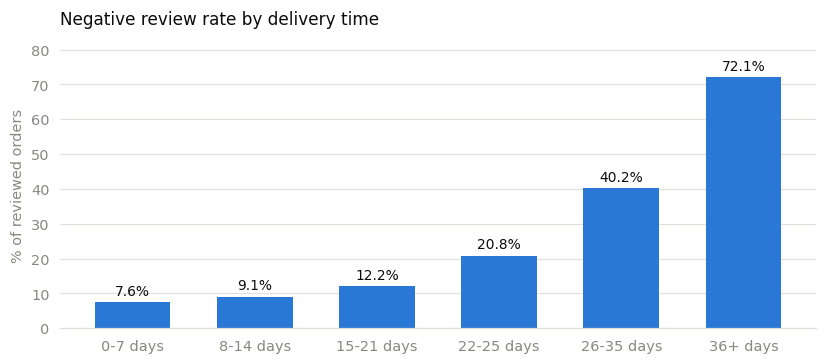

In [15]:
fig, ax = plt.subplots(figsize=(7.6, 3.4))
values = (bucket.negative_rate * 100).astype(float)

ax.bar(bucket.index, values, color=BLUE, width=0.62)
for x, v in zip(bucket.index, values):
    ax.text(x, v + 2, f'{v:.1f}%', ha='center', color=INK, fontsize=9)

ax.set_title('Negative review rate by delivery time', loc='left', fontsize=11, pad=12)
ax.set_ylabel('% of reviewed orders')
ax.set_ylim(0, 82)
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

### 4.4 On time vs late

In [16]:
late = (reviewed[reviewed.is_late.notna()]
        .groupby('is_late')
        .agg(orders=('order_id', 'size'),
             negative_rate=('is_negative_review', 'mean'),
             avg_delivery_days=('delivery_days', 'mean')))
late.index = ['on time / early', 'late']
late['negative_rate_pct'] = (late.negative_rate * 100).round(1)
late[['orders', 'negative_rate_pct', 'avg_delivery_days']].round(1)

,orders,negative_rate_pct,avg_delivery_days
on time / early,89443,9.3,10.9
late,6381,62.4,33.8


Missing the promised delivery date is the strongest single signal in the data: **62.4%** of late orders are negative reviews, compared with **9.3%** when the promised date is met. Late orders also average **33.8 delivery days**, indicating that lateness and long delivery times largely reflect the same underlying issue.

### 4.5 High-risk sellers

In [17]:
seller_stats = seller_reviewed.groupby('seller_id').agg(
    orders=('order_id', 'size'),
    avg_score=('review_score', 'mean'),
    negative_rate=('is_negative_review', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
)

# Flag sellers with at least 50 reviewed orders and an average score below 3.5
eligible = seller_stats.orders >= 50
high_risk_sellers = seller_stats[eligible & (seller_stats.avg_score < 3.5)].sort_values('avg_score')

print(f'sellers with >=50 reviewed orders  : {eligible.sum()}')
print(f'flagged high-risk                  : {len(high_risk_sellers)}')
print(f'lowest negative rate among flagged : {high_risk_sellers.negative_rate.min()*100:.1f}%  (platform average {reviewed.is_negative_review.mean()*100:.1f}%)')
print(f'share of reviewed orders exposed   : {seller_reviewed.seller_id.isin(high_risk_sellers.index).mean()*100:.1f}%')

high_risk_sellers.head(10).round(3)

sellers with >=50 reviewed orders  : 418
flagged high-risk                  : 15
lowest negative rate among flagged : 25.4%  (platform average 12.8%)
share of reviewed orders exposed   : 2.5%


,orders,avg_score,negative_rate,avg_delivery_days
seller_id,,,,
1ca7077d890b907f89be8c954a02686a,107,2.393,0.598,15.486
2eb70248d66e0e3ef83659f71b244378,184,2.793,0.473,17.842
972d0f9cf61b499a4812cf0bfa3ad3c4,79,3.025,0.418,18.266
a49928bcdf77c55c6d6e05e09a9b4ca5,96,3.031,0.406,16.771
54965bbe3e4f07ae045b90b0b8541f52,69,3.145,0.406,26.029
bbad7e518d7af88a0897397ffdca1979,67,3.179,0.403,13.358
5058e8c1e82653974541e83690655b4a,61,3.246,0.311,26.623
8444e55c1f13cd5c179851e5ca5ebd00,92,3.370,0.326,21.000
6fd52c528dcb38be2eea044946b811f8,66,3.394,0.364,21.485


Every flagged seller already has a negative rate well above the platform average, so the average score threshold alone is sufficient to identify high-risk sellers.

### 4.6 High-risk categories

In [18]:
cat_stats = cat_reviewed.groupby('product_category').agg(
    orders=('order_id', 'size'),
    avg_score=('review_score', 'mean'),
    negative_rate=('is_negative_review', 'mean'),
)

high_risk_cats = cat_stats[(cat_stats.orders >= 100) &
                           ((cat_stats.negative_rate > 0.20) | (cat_stats.avg_score < 3.5))] \
                     .sort_values('negative_rate', ascending=False)

print(f'categories with >=100 reviewed orders: {(cat_stats.orders >= 100).sum()}')
print(f'flagged high-risk                    : {len(high_risk_cats)}')
high_risk_cats.round(3)

categories with >=100 reviewed orders: 52
flagged high-risk                    : 3


,orders,avg_score,negative_rate
product_category,,,
fashion_male_clothing,105,3.819,0.229
office_furniture,1244,3.645,0.219
audio,345,3.841,0.217


### 4.7 Geography

In [19]:
state = (reviewed.groupby('customer_state')
         .agg(orders=('order_id', 'size'),
              negative_rate=('is_negative_review', 'mean'),
              avg_review_score=('review_score', 'mean'),
              avg_delivery_days=('delivery_days', 'mean'),
              late_rate=('is_late', 'mean'))
         .sort_values('negative_rate', ascending=False))
state.round(3).head(10)

,orders,negative_rate,avg_review_score,avg_delivery_days,late_rate
customer_state,,,,,
AL,394,0.213,3.848,24.414,0.208
MA,712,0.199,3.833,21.379,0.171
SE,334,0.189,3.907,21.383,0.150
RJ,12211,0.183,3.965,15.170,0.119
PA,933,0.179,3.914,23.594,0.107
CE,1273,0.171,3.944,21.139,0.137
BA,3229,0.170,3.931,19.188,0.119
PI,471,0.161,3.994,19.433,0.138
AC,80,0.150,4.088,21.000,0.038


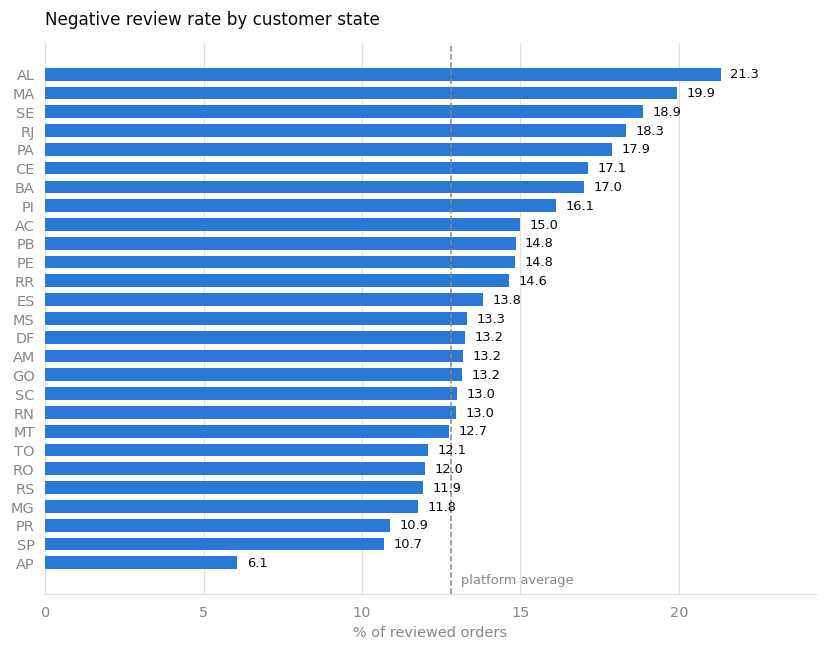

In [20]:
fig, ax = plt.subplots(figsize=(7.6, 6))
s = state.sort_values('negative_rate')
values = (s.negative_rate * 100).astype(float)

ax.barh(s.index, values, color=BLUE, height=0.68)
ax.axvline(reviewed.is_negative_review.mean() * 100, color=MUTED, linewidth=1, linestyle='--')
ax.text(reviewed.is_negative_review.mean() * 100 + 0.3, -0.9, 'platform average',
        color=MUTED, fontsize=8.5, va='center')

for y, v in zip(s.index, values):
    ax.text(v + 0.3, y, f'{v:.1f}', va='center', color=INK, fontsize=8.5)

ax.set_title('Negative review rate by customer state', loc='left', fontsize=11, pad=12)
ax.set_xlabel('% of reviewed orders')
ax.set_xlim(0, values.max() + 3)
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

In [21]:
NORTH_NORTHEAST = {'AC', 'AP', 'AM', 'PA', 'RO', 'RR', 'TO',
                   'AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE'}

region = (reviewed.assign(region=np.where(reviewed.customer_state.isin(NORTH_NORTHEAST),
                                          'North / Northeast', 'Rest of Brazil'))
          .groupby('region')
          .agg(orders=('order_id', 'size'),
               negative_rate=('is_negative_review', 'mean'),
               avg_delivery_days=('delivery_days', 'mean'),
               late_rate=('is_late', 'mean')))
region.round(3)

,orders,negative_rate,avg_delivery_days,late_rate
region,,,,
North / Northeast,10754,0.165,20.296,0.118
Rest of Brazil,85078,0.123,11.464,0.060


The North/Northeast gap is driven more by delivery time than customer preference: states with longer delivery times tend to have higher negative rates (**20.3 vs. 11.5 average delivery days**). SP stands out as the operational benchmark, with the shortest delivery time and the lowest negative rate among high-volume states. AP has an even lower negative rate (**6.1%**), but its small volume of **66 orders** makes it less comparable.

### 4.8 Customer value and segmentation

In [22]:
print(f'customers            : {len(cust):,}')
print(f'one-time buyers      : {(cust.frequency == 1).mean()*100:.1f}%')
print(cust.frequency.value_counts().sort_index().head(6).to_string())

try:
    pd.qcut(cust.frequency, 3)
except ValueError as e:
    print(f'\nqcut(frequency, 3) -> ValueError: {e}')

customers            : 93,358
one-time buyers      : 97.0%
frequency
1    90557
2     2573
3      181
4       28
5        9
6        5

qcut(frequency, 3) -> ValueError: Bin edges must be unique: Index([1.0, 1.0, 1.0, 15.0], dtype='float64', name='frequency').
You can drop duplicate edges by setting the 'duplicates' kwarg


Frequency is highly skewed: **97% of customers bought only once**, so RFM frequency scores would not form meaningful groups. I therefore use frequency as a simple **repeat vs. one-time flag** in the rule-based segmentation rather than assigning a 1–5 score.

In [23]:
cust['monetary_quartile'] = pd.qcut(cust.monetary, 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

def assign_segment(row):
    if row.frequency >= 2:
        return 'At-Risk Loyalists'
    if row.monetary_quartile == 'Q4' and row.recency <= 365:
        return 'High-Value Prospects'
    if row.recency > 365 and row.monetary_quartile in ('Q1', 'Q2'):
        return 'Lapsed Customers'
    return 'Standard Customers'

cust['segment'] = cust.apply(assign_segment, axis=1)

cust.groupby('segment').agg(customers=('frequency', 'size'),
                            avg_recency=('recency', 'mean'),
                            avg_frequency=('frequency', 'mean'),
                            avg_monetary=('monetary', 'mean')).round(1)

,customers,avg_recency,avg_frequency,avg_monetary
segment,,,,
At-Risk Loyalists,2801,220.3,2.1,260.1
High-Value Prospects,16828,175.1,1.0,352.3
Lapsed Customers,10490,462.4,1.0,46.4
Standard Customers,63239,218.2,1.0,96.1


In [24]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(cust[['recency', 'frequency', 'monetary']])
cust['kmeans_cluster'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X)

pd.crosstab(cust.segment, cust.kmeans_cluster)

kmeans_cluster,0,1,2,3
segment,,,,
At-Risk Loyalists,0,0,27,2774
High-Value Prospects,11066,4045,1717,0
Lapsed Customers,0,10490,0,0
Standard Customers,39680,23114,445,0


K-Means shows a similar pattern: repeat buyers and lapsed customers each fall into a single cluster, while one-time buyers are mainly separated by recency and spend. I keep the rule-based segmentation because it is easier to reproduce in Power BI without relying on Python.

In [25]:
rv = reviewed.merge(cust[['segment']], left_on='customer_unique_id', right_index=True)
rv['order_value_quartile'] = pd.qcut(rv.order_value, 4, labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'])

by_value = (rv.groupby('order_value_quartile', observed=True)
              .agg(orders=('order_id', 'size'), negative_rate=('is_negative_review', 'mean')))
by_value['negative_rate_pct'] = (by_value.negative_rate * 100).round(1)

by_segment = (rv.groupby('segment')
                .agg(orders=('order_id', 'size'), negative_rate=('is_negative_review', 'mean'))
                .sort_values('negative_rate', ascending=False))
by_segment['negative_rate_pct'] = (by_segment.negative_rate * 100).round(1)

display(by_value[['orders', 'negative_rate_pct']])
display(by_segment[['orders', 'negative_rate_pct']])

,orders,negative_rate_pct
order_value_quartile,,
Q1 (lowest),24102,10.9
Q2,23815,12.1
Q3,24211,12.8
Q4 (highest),23704,15.5


,orders,negative_rate_pct
segment,,
High-Value Prospects,16696,16.6
Standard Customers,62841,12.3
At-Risk Loyalists,5869,11.8
Lapsed Customers,10426,10.2


Dissatisfaction increases with order value: higher-value orders are more likely to receive a 1–2 star review. This suggests that service recovery should not focus only on low-value orders.

### 4.9 Hidden-risk sellers

In [26]:
# sellers that look acceptable platform-wide but underperform for repeat customers
repeat_customers = set(cust.index[cust.frequency >= 2])

os_cust = seller_reviewed.merge(orders[['order_id', 'customer_unique_id']], on='order_id')
os_cust['is_repeat'] = os_cust.customer_unique_id.isin(repeat_customers)

overall = os_cust.groupby('seller_id').agg(orders=('order_id', 'size'),
                                           negative_rate=('is_negative_review', 'mean'))
repeat = (os_cust[os_cust.is_repeat].groupby('seller_id')
          .agg(repeat_orders=('order_id', 'size'),
               repeat_negative_rate=('is_negative_review', 'mean')))

hidden = overall.join(repeat, how='inner')
hidden_risk_sellers = hidden[(hidden.repeat_orders >= 5) &
                             (hidden.negative_rate < 0.20) &
                             (hidden.repeat_negative_rate >= 0.30)] \
                          .sort_values('repeat_negative_rate', ascending=False)

print(f'hidden-risk sellers: {len(hidden_risk_sellers)} '
      f'(of which already flagged in 4.5: {hidden_risk_sellers.index.isin(high_risk_sellers.index).sum()})')
hidden_risk_sellers.round(3).head(10)

hidden-risk sellers: 12 (of which already flagged in 4.5: 0)


,orders,negative_rate,repeat_orders,repeat_negative_rate
seller_id,,,,
1e8b33f18b4f7598d87f5cbee2282cc2,120,0.108,9,0.444
f5a590cf36251cf1162ea35bef76fe84,113,0.106,7,0.429
00fc707aaaad2d31347cf883cd2dfe10,102,0.157,12,0.417
0db783cfcd3b73998abc6e10e59a102f,131,0.130,5,0.400
c826c40d7b19f62a09e2d7c5e7295ee2,345,0.142,10,0.400
f4aba7c0bca51484c30ab7bdc34bcdd1,108,0.157,5,0.400
522620dcb18a6b31cd7bdf73665113a9,169,0.189,8,0.375
0be8ff43f22e456b4e0371b2245e4d01,156,0.173,6,0.333
5160d23075764e18e07c1f4a87fad743,33,0.091,6,0.333


### 4.10 Impact scenario

In [27]:
risk = reviewed[['order_id', 'is_negative_review', 'delivery_days']].copy()
risk['delivery_risk'] = risk.delivery_days > 25
risk['seller_risk']   = risk.order_id.isin(seller_reviewed.loc[seller_reviewed.seller_id.isin(high_risk_sellers.index), 'order_id'])
risk['category_risk'] = risk.order_id.isin(cat_reviewed.loc[cat_reviewed.product_category.isin(high_risk_cats.index), 'order_id'])
risk['any_risk']      = risk[['delivery_risk', 'seller_risk', 'category_risk']].any(axis=1)

exposure = pd.DataFrame({
    factor: {
        'orders_affected': int(risk[factor].sum()),
        'share_of_orders_pct': round(risk[factor].mean() * 100, 1),
        'negative_rate_when_present_pct': round(risk.loc[risk[factor], 'is_negative_review'].mean() * 100, 1),
        'negative_rate_when_absent_pct': round(risk.loc[~risk[factor], 'is_negative_review'].mean() * 100, 1),
    } for factor in ['delivery_risk', 'seller_risk', 'category_risk', 'any_risk']
}).T
exposure

,orders_affected,share_of_orders_pct,negative_rate_when_present_pct,negative_rate_when_absent_pct
delivery_risk,7123.0,7.4,51.6,9.7
seller_risk,2409.0,2.5,32.7,12.3
category_risk,1694.0,1.8,22.0,12.6
any_risk,9629.0,10.0,44.3,9.3


In [28]:
actual   = risk.is_negative_review.mean()
no_risk  = risk.loc[~risk.any_risk, 'is_negative_review'].mean()
no_deliv = risk.loc[~risk.delivery_risk, 'is_negative_review'].mean()

print(f'actual dissatisfaction rate            : {actual*100:.2f}%')
print(f'if delivery risk were resolved         : {no_deliv*100:.2f}%   ({(actual-no_deliv)*100:.2f} pp)')
print(f'if all three risk factors were resolved: {no_risk*100:.2f}%   ({(actual-no_risk)*100:.2f} pp)')

actual dissatisfaction rate            : 12.81%
if delivery risk were resolved         : 9.70%   (3.11 pp)
if all three risk factors were resolved: 9.29%   (3.52 pp)


This is a directional estimate, not a causal result. It assumes that risk-exposed orders would perform similarly to unexposed orders. Under this assumption, delivery accounts for most of the potential gap.

## 5. Output for Power BI

In [29]:
score_edges = [-np.inf, 3.5, 3.9, 4.1, 4.5, np.inf]
score_labels = ['<3.5', '3.5 - 3.9', '3.9 - 4.1', '4.1 - 4.5', '4.5+']
neg_edges = [-np.inf, 0.05, 0.10, 0.15, 0.20, np.inf]
neg_labels = ['<5%', '5-10%', '10-15%', '15-20%', '20%+']

seller_risk = seller_stats.assign(
    is_high_risk=seller_stats.index.isin(high_risk_sellers.index).astype(int),
    is_hidden_risk=seller_stats.index.isin(hidden_risk_sellers.index).astype(int),
    score_bucket=pd.cut(seller_stats.avg_score, bins=score_edges, labels=score_labels),
    score_bucket_order=pd.cut(seller_stats.avg_score, bins=score_edges, labels=[1, 2, 3, 4, 5]).astype('Int64'),
    neg_rate_bucket=pd.cut(seller_stats.negative_rate.astype(float), bins=neg_edges, labels=neg_labels),
    neg_rate_bucket_order=pd.cut(seller_stats.negative_rate.astype(float), bins=neg_edges, labels=[1, 2, 3, 4, 5]).astype('Int64'),
).round(4).reset_index()

category_risk = cat_stats.assign(
    is_high_risk=cat_stats.index.isin(high_risk_cats.index).astype(int),
).round(4).reset_index()

customer_segment = cust[['recency', 'frequency', 'monetary', 'monetary_quartile', 'segment']] \
                       .round(2).reset_index()

exports = {
    'dim_seller_risk':      seller_risk,
    'dim_category_risk':    category_risk,
    'dim_customer_segment': customer_segment,
}

for name, df in exports.items():
    assert df.notna().all().all(), f'{name} contains nulls'
    df.to_csv(OUT / f'{name}.csv', index=False, encoding='utf-8')
    print(f'{name:22s} {len(df):>7,d} rows x {df.shape[1]} cols -> outputs/{name}.csv')

assert customer_segment.customer_unique_id.is_unique
assert seller_risk.seller_id.is_unique

dim_seller_risk          2,965 rows x 11 cols -> outputs/dim_seller_risk.csv
dim_category_risk           74 rows x 5 cols -> outputs/dim_category_risk.csv
dim_customer_segment    93,358 rows x 6 cols -> outputs/dim_customer_segment.csv
